In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Visualizing Contributor Co-occurrence in the ProvedIt Dataset

This notebook explores the contributor structure of the ProvedIt dataset. The goal is to analyze how contributors co-occur within files and visualize their relationships using an arc diagram.

In [2]:
from itertools import combinations
from collections import Counter
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer, categorize_files
from DNAnet.data.parsing.file_parsing import find_files_by_suffix

import matplotlib.pyplot as plt
import numpy as np

# Load Dataset Files

- Specify the path to the dataset and load all files with the `.hid` suffix. These files are used to extract contributor information.
- Categorize the loaded files using the custom file categorizer and extract the subset of files labeled as 'sample', which represent mixture samples.
- Display the number of mixture samples identified in the dataset.

In [3]:
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
hid_files = find_files_by_suffix(hid_files_path, ".hid")

categorized_files = categorize_files(hid_files, ProvedItFileCategorizer())
mixture_samples = categorized_files["sample"]

len(mixture_samples)

675

## Extract and Count Contributor Pairs

Extract all contributor pairs from the files and count the frequency of each pair's co-occurrence.

In [4]:
def extract_all_pairs(files):
    pairs = []
    for f in files:
        ids = ProvedItFileCategorizer.extract_contributor_ids(f.name)
        # Only consider files with at least 2 contributors
        if len(ids) >= 2:
            # Get all unique pairs (order doesn't matter)
            pairs.extend(combinations(sorted(ids), 2))
    return pairs

In [5]:
pairs = extract_all_pairs(mixture_samples)
pairs_count = Counter(pairs)
pairs_count.most_common(10)

[((33, 34), 122),
 ((36, 37), 107),
 ((29, 50), 100),
 ((44, 45), 99),
 ((31, 32), 98),
 ((37, 38), 97),
 ((29, 49), 84),
 ((49, 50), 84),
 ((30, 31), 83),
 ((46, 47), 83)]

## Visualize Contributor Co-occurrence

Define a function to visualize contributor co-occurrence as an arc diagram. Each contributor is represented along a line, and arcs connect contributors who appear together in the same file.

In [72]:
def plot_arc_diagram(pairs, num_ids=25):
    plt.figure(figsize=(12, 4))
    y = np.zeros(num_ids)
    x = np.arange(29-3, num_ids + 29-3)
    plt.scatter(x, y, s=50, color='black')

    for a, b in pairs:
        # Draw an arc between a and b
        mid = (a + b) / 2
        radius = abs(b - a) / 2
        theta = np.linspace(0, np.pi, 100)
        arc_x = mid + radius * np.cos(theta)
        arc_y = radius * np.sin(theta)
        plt.plot(arc_x, arc_y, color='blue', alpha=0.3)

    plt.yticks([])
    plt.xlabel("Contributor ID")
    plt.title("Contributor Co-occurrence Arc Diagram")
    plt.show()

## Plot the Arc Diagram

Generate and display the arc diagram to visualize the relationships between contributors based on their co-occurrence in files.

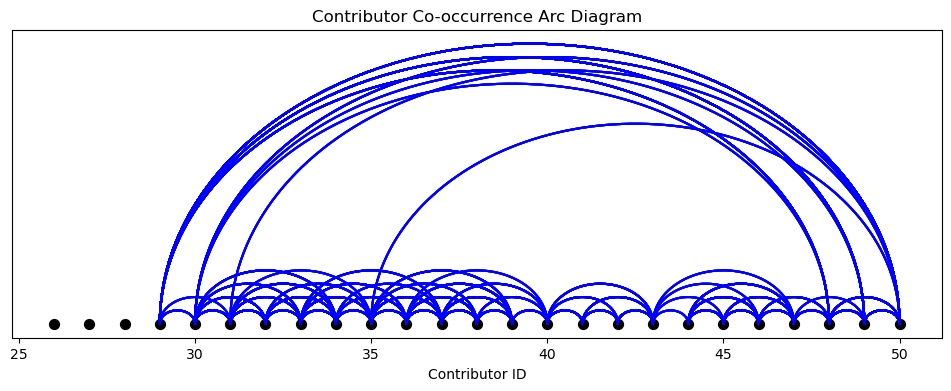

In [73]:
plot_arc_diagram(pairs)

# Constructing Graphs of Contributor Interconnectivity

We will construct two types of graphs:
1. A weighted undirected graph where nodes are contributors and edges represent co-occurrence in files, weighted by the number of co-occurrences.
2. A bipartite graph with files on one side and contributors on the other, with edges indicating which contributors are present in which files.

## Weighted Graph

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import nxmetis
from sklearn.cluster import SpectralClustering

In [9]:
# 1. Weighted undirected graph of contributor co-occurrence
G_contrib = nx.Graph()
for (a, b), weight in pairs_count.items():
    G_contrib.add_edge(a, b, weight=weight)

print(f"Contributor graph: {G_contrib.number_of_nodes()} nodes, {G_contrib.number_of_edges()} edges")


Contributor graph: 22 nodes, 64 edges


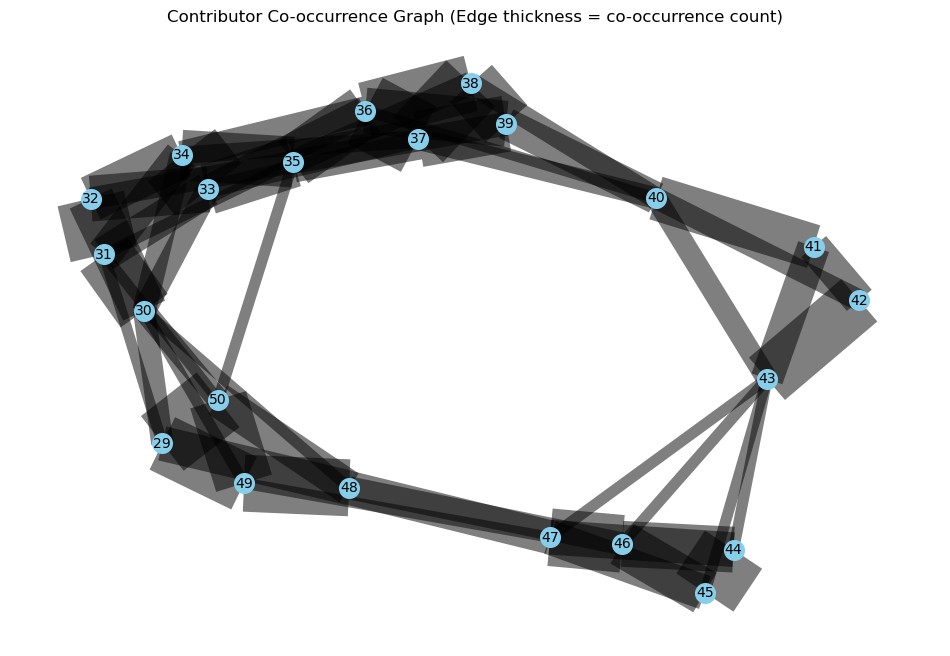

In [87]:
# 1. Visualize the weighted contributor co-occurrence graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_contrib, seed=42, k=0.5)
edges = G_contrib.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]
nx.draw_networkx_nodes(G_contrib, pos, node_size=200, node_color='skyblue')
nx.draw_networkx_edges(G_contrib, pos, width=[w/2 for w in weights], alpha=0.5) # type: ignore
nx.draw_networkx_labels(G_contrib, pos, font_size=10)
plt.title("Contributor Co-occurrence Graph (Edge thickness = co-occurrence count)")
plt.axis('off')
plt.show()

## Splitting the Graph into Communities (using spectral clustering)

In [52]:
# # Option A: Use Stoer-Wagner for 2 sets - Only 2 sets???
# cut_value, partition = nx.stoer_wagner(G_contrib)
# partitions = [set(partition[0]), set(partition[1])]
# partitions

# # Option B: Use METIS for partitioning
# # Now partition
# edgecuts, partitions = nxmetis.partition(G_contrib, 2)

# print("Edge cuts:", edgecuts)
# print("Partition 1:", partitions[0])
# print("Partition 2:", partitions[1])

# # Check if partitions meet your minimum size constraint
# if len(partitions[0]) >= 3 and len(partitions[1]) >= 3:
#     print("Valid partition found!")
# else:
#     print("One partition is too small. Try another seed or fallback.")

# Option C: Use scikit's spectral clustering - WORKS BEST
# Build adjacency matrix
N_COMMUNITIES = 5
nodes = list(G_contrib.nodes())
node_idx = {node: i for i, node in enumerate(nodes)}
A = np.zeros((len(nodes), len(nodes)))

for u, v, data in G_contrib.edges(data=True):
    i, j = node_idx[u], node_idx[v]
    A[i, j] = A[j, i] = data.get("weight", 1)

# Run spectral clustering
clustering = SpectralClustering(n_clusters=N_COMMUNITIES, affinity='precomputed', assign_labels='kmeans')
labels = clustering.fit_predict(A)

community_dict = {u:int(c) for u,c in zip(nodes, labels)}
# group nodes by community
communities = {}
for node, comm in community_dict.items():
    communities.setdefault(comm, set()).add(node)

partitions = list(communities.values())
partitions

[{35, 36, 37, 38, 39},
 {40, 41, 42, 43},
 {30, 31, 32, 33, 34},
 {29, 48, 49, 50},
 {44, 45, 46, 47}]

### Visualize weighted graph split

/var/folders/gn/8cmn0qdj1mx7g0mxnt5q722h0000gp/T/ipykernel_60863/3239775988.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', num_communities)  # or 'tab20' for more colors


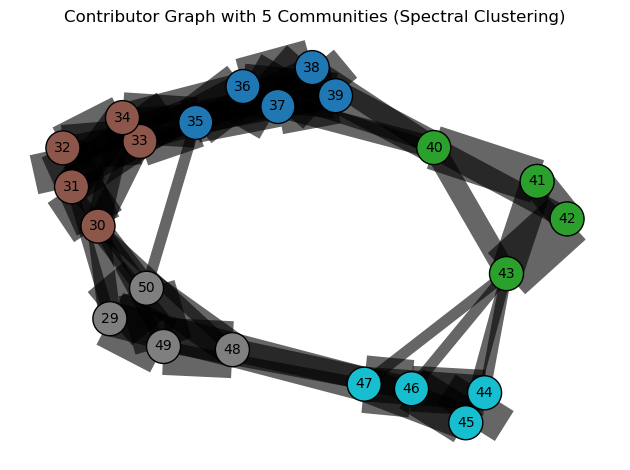

In [53]:
import matplotlib.cm as cm

pos = nx.spring_layout(G_contrib, seed=42, k=0.5)  # Layout positions (force-directed)

# Assign a color to each community
num_communities = len(partitions)
colors = cm.get_cmap('tab10', num_communities)  # or 'tab20' for more colors

# Build a mapping: node -> community index
node_to_comm = {}
for idx, comm in enumerate(partitions):
    for node in comm:
        node_to_comm[node] = idx

# Color nodes by community
node_colors = [colors(node_to_comm[node]) for node in G_contrib.nodes()]

# Draw edges (thickness proportional to weight)
edge_weights = [G_contrib[u][v]['weight'] for u, v in G_contrib.edges()]
nx.draw_networkx_edges(G_contrib, pos, width=[w * 0.5 for w in edge_weights], alpha=0.6)

# Draw nodes
nx.draw_networkx_nodes(G_contrib, pos, node_color=node_colors, node_size=600, edgecolors='k')
nx.draw_networkx_labels(G_contrib, pos, font_size=10)

plt.title("Contributor Graph with 5 Communities (Spectral Clustering)")
plt.axis("off")
plt.tight_layout()
plt.show()

## TODO: Measure/Visualize the purity and equality of the splits
* Purity: What fraction of EPGs is discarded on average?
* Equality: What is the gini coefficient of the partitions sizes?

## Bipartite Graph

In [83]:
# 2. Bipartite graph: files <-> contributors
B = nx.Graph()
file_nodes = []
contrib_nodes = set()

for f in mixture_samples:
    file_id = f.name  # or use f.path if you want full path
    file_nodes.append(file_id)  # Just the filename
    contribs = ProvedItFileCategorizer.extract_contributor_ids(f.name)
    for c in contribs:
        B.add_edge(file_id, c)
        contrib_nodes.add(c)

# Mark node attributes for bipartite sets
for f in file_nodes:
    B.nodes[f]['bipartite'] = 0  # files
for c in contrib_nodes:
    B.nodes[c]['bipartite'] = 1  # contributors

print(f"Bipartite graph: {len(file_nodes)} file nodes, {len(contrib_nodes)} contributor nodes, {B.number_of_edges()} edges")


Bipartite graph: 675 file nodes, 22 contributor nodes, 2341 edges


### Splitting the bipartite graph into communities

In [84]:
# Create a lookup: file -> set of contributors
file_to_contribs = {f: set(B.neighbors(f)) for f in file_nodes}

# Shuffle or sort to influence behavior
sorted_files = sorted(file_nodes, key=lambda f: len(file_to_contribs[f]))

# Partition containers
partitions = {"A": set(), "B": set()}
contributors_in = {"A": set(), "B": set()}
unassigned_files = set(file_nodes)

# Helper: assign file to partition
def assign_file(f, part):
    partitions[part].add(f)
    contributors_in[part].update(file_to_contribs[f])
    unassigned_files.discard(f)

# Step 1: Seed one file per partition (non-overlapping contributors)
assign_file(sorted_files[0], "A")
for f in sorted_files[1:]:
    if file_to_contribs[f].isdisjoint(contributors_in["A"]):
        assign_file(f, "B")
        break

# Step 2: Greedy assignment
for f in sorted_files:
    if f not in unassigned_files:
        continue
    cset = file_to_contribs[f]
    can_A = cset.isdisjoint(contributors_in["A"])
    can_B = cset.isdisjoint(contributors_in["B"])

    if can_A and (len(partitions["A"]) < len(partitions["B"]) or not can_B):
        assign_file(f, "A")
    elif can_B:
        assign_file(f, "B")
    else:
        continue  # can't assign without overlap

# Step 3: Enforce minimum size constraint
if len(partitions["A"]) < 3 or len(partitions["B"]) < 3:
    print("⚠️ No valid split with ≥3 files per side found.")
else:
    print(f"✅ Partition A: {len(partitions['A'])} files, Partition B: {len(partitions['B'])} files")
    print(f"Unassigned: {len(unassigned_files)} files")

# Optional: Inspect contributors per partition
#print("Contributors in A:", contributors_in["A"])
#print("Contributors in B:", contributors_in["B"])


✅ Partition A: 8 files, Partition B: 8 files
Unassigned: 659 files


### Visualize bipartite Graph

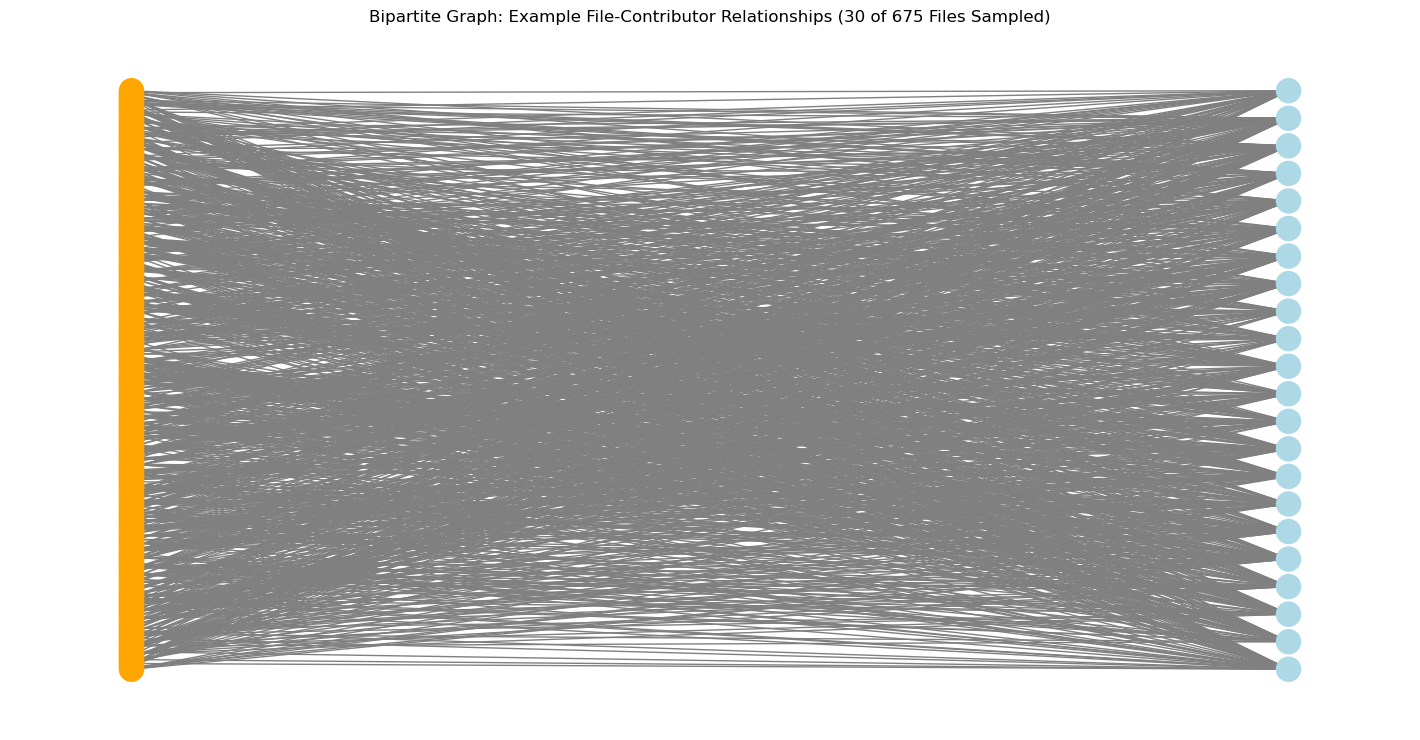

In [90]:
# Optionally, visualize a small subgraph of the bipartite graph (files and contributors)
# Pick a random sample of files and their contributors for visualization
sampled_files = random.sample(list(file_nodes), min(300, len(file_nodes)))
sub_nodes = set(sampled_files)
for f in sampled_files:
    sub_nodes.update(B.neighbors(f))
subgraph = B.subgraph(sub_nodes)

plt.figure(figsize=(14, 7))
# pos = nx.spring_layout(subgraph, seed=42, k=0.7)
pos = nx.bipartite_layout(subgraph, nodes=sampled_files)
node_colors = ['orange' if n in sampled_files else 'lightblue' for n in subgraph.nodes()]
nx.draw(subgraph, pos, with_labels=False, node_color=node_colors, node_size=300, font_size=8, edge_color='gray')
plt.title("Bipartite Graph: Example File-Contributor Relationships (30 of 675 Files Sampled)")
plt.axis('off')
plt.show()

# Ultimate Separation Heuristic

In [16]:
# Step 1: Define contributor set of interest (Community A)
communities_found = [
    ({30, 31, 32, 33, 34}, 17.0), 
    ({35, 36, 37, 38, 39}, 12.2), 
    ({40, 41, 42, 43}, 18.4), 
    ({44, 45, 46, 47}, 13.6), 
    ({29, 48, 49, 50}, 14.5)]  # Store found communities to avoid repeats
community_A_contributors = {35, 36, 37, 38, 39}  # Keep as strings if IDs are strings

# Step 2: Classify files
community_A_files = []
community_B_files = []
ambiguous_files = []

for f in mixture_samples:
    contribs = set(ProvedItFileCategorizer.extract_contributor_ids(f.name))
    # print(f"File: {f.name}, Contributors: {contribs}")

    if contribs.issubset(community_A_contributors):
        community_A_files.append(f)
    elif contribs.isdisjoint(community_A_contributors):
        community_B_files.append(f)
    else:
        ambiguous_files.append(f)  # contributors from both groups, discard or flag

# Step 3: Reporting
print(f"✅ Community A: {len(community_A_files)} files")
print(f"✅ Community B: {len(community_B_files)} files")
# print the ratio of community A to all files
ratio_A = len(community_A_files) / (len(community_A_files) + len(community_B_files))
print(f"ℹ️ Ratio of Community A files to all files: {ratio_A:.2%}")
print(f"⚠️ Ambiguous: {len(ambiguous_files)} files discarded due to overlap")

ind = 2
community_A_files[:ind], community_B_files[:ind], ambiguous_files[:ind]

✅ Community A: 66 files
✅ Community B: 474 files
ℹ️ Ratio of Community A files to all files: 12.22%
⚠️ Ambiguous: 135 files discarded due to overlap


([PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/G10_RD14-0003-35_36_37_38_39-1,4,4,4,1-M2e-0.21GF-Q2.5_07.5sec.hid'),
  PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/D09_RD14-0003-35_36_37_38_39-1,4,4,4,1-M2a-0.5GF-Q0.6_04.5sec.hid')],
 [PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/F01_RD14-0003-31_32-1,1-M1c-0.25GF-Q3.0_06.5sec.hid'),
  PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/D04_RD14-0003-33_34-1,2-M4d-0.093GF-Q1.3_04.5sec.hid')],
 [PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cy